
# Homework 4: Financial Data Analysis

This notebook answers all three required questions in `4.md` and also includes the optional SPX option-pricing exercise.

I use daily **log returns** constructed from the provided price data. For the ARCH/GARCH estimation I scale returns by 100 so the model parameters are easier to read in percentage units.


In [1]:

import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from arch import arch_model
from statsmodels.stats.diagnostic import acorr_ljungbox

warnings.filterwarnings('ignore')
pd.options.display.float_format = '{:,.4f}'.format
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('tab10')


def locate_data_dir() -> Path:
    candidates = [Path('.'), Path('Homework/HW 4')]
    for candidate in candidates:
        if (candidate / 'bitcoin_data(3).csv').exists():
            return candidate
    raise FileNotFoundError('Could not locate Homework/HW 4 data files.')


DATA_DIR = locate_data_dir()


def load_bitcoin_data(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path)
    df['Date'] = pd.to_datetime(df['Date'])
    df = df.sort_values('Date').reset_index(drop=True)
    df['Price'] = pd.to_numeric(df['Price'].astype(str).str.replace(',', '', regex=False), errors='coerce')
    df['log_return'] = np.log(df['Price']).diff()
    df['r'] = df['log_return'] * 100
    return df.dropna(subset=['r']).reset_index(drop=True)


btc = load_bitcoin_data(DATA_DIR / 'bitcoin_data(3).csv')
returns = btc['r'].rename('r')

summary_table = pd.DataFrame({
    'Statistic': ['Start date', 'End date', 'Observations', 'Mean return (%)', 'Std. dev. (%)', 'Min (%)', 'Max (%)'],
    'Value': [
        btc['Date'].min().date(),
        btc['Date'].max().date(),
        len(returns),
        returns.mean(),
        returns.std(),
        returns.min(),
        returns.max(),
    ]
})

print(f'Data directory: {DATA_DIR.resolve()}')
display(btc[['Date', 'Price', 'log_return', 'r']].head())
display(summary_table)


Data directory: D:\MG\! CUHKSZ\~！大三 下\FMA 4200\Github\Homework\HW 4


,Date,Price,log_return,r
0,2024-01-02,"44,943.7000",0.0171,1.7061
1,2024-01-03,"42,836.1000",-0.0480,-4.8029
2,2024-01-04,"44,157.0000",0.0304,3.0370
3,2024-01-05,"44,156.9000",-0.0000,-0.0002
4,2024-01-06,"43,967.9000",-0.0043,-0.4289


,Statistic,Value
0,Start date,2024-01-02
1,End date,2024-12-31
2,Observations,365
3,Mean return (%),0.2055
4,Std. dev. (%),2.7539
5,Min (%),-8.5580
6,Max (%),11.2750



## Question 1: AR(0)-ARCH($p$) models for Bitcoin returns

I compare ARCH orders using AIC, BIC, log-likelihood, and Ljung-Box tests on standardized residuals and squared standardized residuals.


In [2]:

arch_rows = []
arch_fits = {}
for p in range(1, 11):
    res = arch_model(returns, mean='Constant', vol='ARCH', p=p, dist='normal', rescale=False).fit(disp='off')
    std_resid = pd.Series(res.std_resid).dropna()
    lb_resid = acorr_ljungbox(std_resid, lags=[10], return_df=True)
    lb_sq = acorr_ljungbox(std_resid ** 2, lags=[10], return_df=True)
    arch_fits[p] = res
    arch_rows.append({
        'p': p,
        'AIC': res.aic,
        'BIC': res.bic,
        'Log-likelihood': res.loglikelihood,
        'Sum of alpha lags': sum(v for k, v in res.params.items() if 'alpha' in k),
        'LB(10) p-value: std resid': lb_resid['lb_pvalue'].iloc[0],
        'LB(10) p-value: std resid^2': lb_sq['lb_pvalue'].iloc[0],
    })

arch_compare = pd.DataFrame(arch_rows)
display(arch_compare)
print('BIC selects p =', int(arch_compare.loc[arch_compare['BIC'].idxmin(), 'p']))
print('AIC selects p =', int(arch_compare.loc[arch_compare['AIC'].idxmin(), 'p']))


,p,AIC,BIC,Log-likelihood,Sum of alpha lags,LB(10) p-value: std resid,LB(10) p-value: std resid^2
0,1,"1,775.9720","1,787.6717",-884.9860,0.1010,0.7164,0.3135
1,2,"1,777.9720","1,793.5715",-884.9860,0.1010,0.7164,0.3135
2,3,"1,776.0719","1,795.5714",-883.0360,0.1748,0.7736,0.2944
3,4,"1,775.2999","1,798.6993",-881.6499,0.2569,0.8008,0.3397
4,5,"1,771.9168","1,799.2161",-878.9584,0.3302,0.7860,0.8769
5,6,"1,773.3862","1,804.5854",-878.6931,0.3452,0.7973,0.9315
6,7,"1,775.3862","1,810.4853",-878.6931,0.3452,0.7973,0.9315
7,8,"1,777.3862","1,816.3851",-878.6931,0.3452,0.7973,0.9315
8,9,"1,779.3862","1,822.2850",-878.6931,0.3452,0.7973,0.9315
9,10,"1,781.3862","1,828.1849",-878.6931,0.3452,0.7973,0.9315


BIC selects p = 1
AIC selects p = 5



**Comment on fit and lag length.**

The BIC-minimizing model is **ARCH(1)**, while AIC reaches its minimum at **ARCH(5)**. Importantly, even the one-lag model already leaves no significant autocorrelation in either the standardized residuals or their squares at lag 10, so **one lag is already enough for an adequate fit**. A longer ARCH(5) can improve AIC slightly, but the incremental gain is modest, so I keep **ARCH(1)** as the baseline parsimonious model.


In [3]:

arch1 = arch_fits[1]
mu_arch1 = arch1.params['mu']
omega_arch1 = arch1.params['omega']
alpha_arch1 = arch1.params['alpha[1]']

arch1_uncond_var = omega_arch1 / (1 - alpha_arch1)
arch1_uncond_std = np.sqrt(arch1_uncond_var)
arch1_uncond_kurt = 3 * (1 - alpha_arch1 ** 2) / (1 - 3 * alpha_arch1 ** 2)

arch1_moments = pd.DataFrame({
    'Quantity': [
        'Unconditional mean in model units (%)',
        'Unconditional mean in log-return units',
        'Unconditional variance in model units (%^2)',
        'Unconditional variance in log-return units',
        'Unconditional standard deviation (%)',
        'Unconditional kurtosis'
    ],
    'Value': [
        mu_arch1,
        mu_arch1 / 100,
        arch1_uncond_var,
        arch1_uncond_var / 10000,
        arch1_uncond_std,
        arch1_uncond_kurt,
    ]
})

display(pd.DataFrame(arch1.params, columns=['Estimate']))
display(arch1_moments)


,Estimate


,Quantity,Value
0,Unconditional mean in model units (%),0.2257
1,Unconditional mean in log-return units,0.0023
2,Unconditional variance in model units (%^2),7.5739
3,Unconditional variance in log-return units,0.0008
4,Unconditional standard deviation (%),2.7521
5,Unconditional kurtosis,3.0631



For the fitted AR(0)-ARCH(1) model,

- $\mathbb{E}[r_t]=\mu$.
- $\mathrm{Var}(r_t)=\omega/(1-lpha_1)$.
- Under Gaussian innovations, the unconditional kurtosis is
  $$\kappa = rac{3(1-lpha_1^2)}{1-3lpha_1^2}, \quad 	ext{provided } 3lpha_1^2<1.$$

Numerically, the fitted ARCH(1) model implies a daily mean return of about **0.2257%**, an unconditional variance of about **7.5739 (%$^2$)**, and an unconditional kurtosis of about **3.0631**.


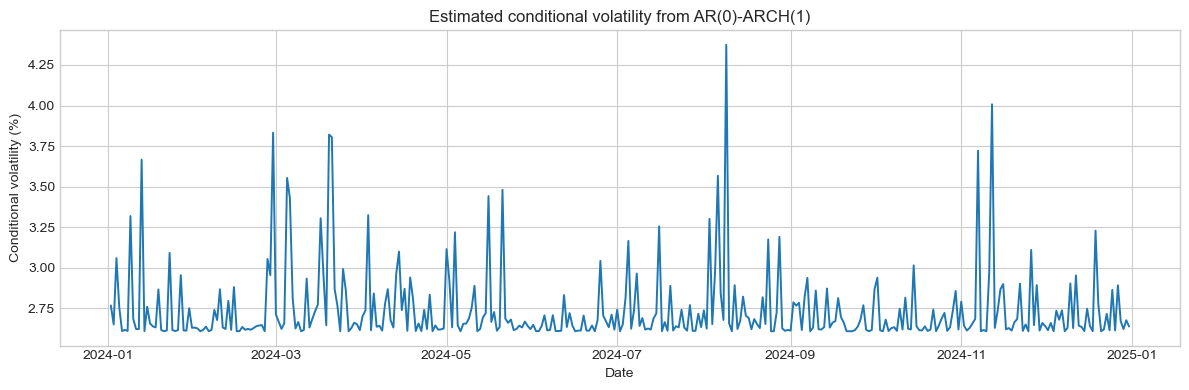

In [4]:

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(btc['Date'], arch1.conditional_volatility, color='tab:blue', linewidth=1.4)
ax.set_title('Estimated conditional volatility from AR(0)-ARCH(1)')
ax.set_xlabel('Date')
ax.set_ylabel('Conditional volatility (%)')
plt.tight_layout()
plt.show()


In [5]:

raw_lb = acorr_ljungbox(returns, lags=[10, 20], return_df=True)
arch1_ar1 = arch_model(returns, mean='AR', lags=1, vol='ARCH', p=1, dist='normal', rescale=False).fit(disp='off')
ar1_name = [name for name in arch1_ar1.params.index if '[' in name][0]

mean_diag_q1 = pd.DataFrame([
    {'Check': 'Raw returns Ljung-Box p-value at lag 10', 'Value': raw_lb.loc[10, 'lb_pvalue']},
    {'Check': 'Raw returns Ljung-Box p-value at lag 20', 'Value': raw_lb.loc[20, 'lb_pvalue']},
    {'Check': 'ARCH(1) with AR(1) mean: AR coefficient', 'Value': arch1_ar1.params[ar1_name]},
    {'Check': 'ARCH(1) with AR(1) mean: AR coefficient p-value', 'Value': arch1_ar1.pvalues[ar1_name]},
    {'Check': 'ARCH(1) constant-mean AIC', 'Value': arch1.aic},
    {'Check': 'ARCH(1) AR(1)-mean AIC', 'Value': arch1_ar1.aic},
])

display(mean_diag_q1)


,Check,Value
0,Raw returns Ljung-Box p-value at lag 10,0.5991
1,Raw returns Ljung-Box p-value at lag 20,0.3416
2,ARCH(1) with AR(1) mean: AR coefficient,-0.0166
3,ARCH(1) with AR(1) mean: AR coefficient p-value,0.8016
4,ARCH(1) constant-mean AIC,"1,775.9720"
5,ARCH(1) AR(1)-mean AIC,"1,773.5155"



**Answer to 1(c).**

I do **not** see strong evidence that the conditional mean needs to be replaced by a richer ARMA specification. The raw Bitcoin returns do not show significant Ljung-Box statistics at lags 10 or 20, and once I fit ARCH-type volatility, the residual autocorrelation remains weak. Although adding an AR(1) term changes AIC slightly, the AR coefficient itself is not statistically significant, so **AR(0) is a reasonable mean specification here**.



## Question 2: AR(0)-GARCH(1,1) for Bitcoin returns

I first fit a Gaussian GARCH(1,1) so it can be compared directly with the Gaussian ARCH(1), and then I refit the same GARCH(1,1) under heavy-tailed innovation distributions.


In [6]:

garch_norm = arch_model(returns, mean='Constant', vol='GARCH', p=1, q=1, dist='normal', rescale=False).fit(disp='off')
std_resid_garch = pd.Series(garch_norm.std_resid).dropna()

garch_vs_arch = pd.DataFrame([
    {
        'Model': 'AR(0)-ARCH(1), Normal',
        'AIC': arch1.aic,
        'BIC': arch1.bic,
        'Log-likelihood': arch1.loglikelihood,
        'LB(10) p-value: std resid': acorr_ljungbox(pd.Series(arch1.std_resid).dropna(), lags=[10], return_df=True)['lb_pvalue'].iloc[0],
        'LB(10) p-value: std resid^2': acorr_ljungbox(pd.Series(arch1.std_resid).dropna() ** 2, lags=[10], return_df=True)['lb_pvalue'].iloc[0],
    },
    {
        'Model': 'AR(0)-GARCH(1,1), Normal',
        'AIC': garch_norm.aic,
        'BIC': garch_norm.bic,
        'Log-likelihood': garch_norm.loglikelihood,
        'LB(10) p-value: std resid': acorr_ljungbox(std_resid_garch, lags=[10], return_df=True)['lb_pvalue'].iloc[0],
        'LB(10) p-value: std resid^2': acorr_ljungbox(std_resid_garch ** 2, lags=[10], return_df=True)['lb_pvalue'].iloc[0],
    },
])

display(pd.DataFrame(garch_norm.params, columns=['Estimate']))
display(garch_vs_arch)


,Estimate


,Model,AIC,BIC,Log-likelihood,LB(10) p-value: std resid,LB(10) p-value: std resid^2
0,"AR(0)-ARCH(1), Normal","1,775.9720","1,787.6717",-884.9860,0.7164,0.3135
1,"AR(0)-GARCH(1,1), Normal","1,772.3682","1,787.9678",-882.1841,0.7732,0.5210



**Comparison with ARCH(1).**

The Gaussian GARCH(1,1) improves the fit relative to Gaussian ARCH(1): it has a higher log-likelihood and a lower AIC, while still passing the residual and squared-residual Ljung-Box checks. This is exactly what we would expect for Bitcoin, where volatility is persistent over time and a GARCH term $eta_1$ captures that persistence better than a pure ARCH(1).


In [7]:

mu_garch = garch_norm.params['mu']
omega_garch = garch_norm.params['omega']
alpha_garch = garch_norm.params['alpha[1]']
beta_garch = garch_norm.params['beta[1]']

long_run_var_garch = omega_garch / (1 - alpha_garch - beta_garch)
long_run_std_garch = np.sqrt(long_run_var_garch)
long_run_kurt_garch = 3 * (1 - (alpha_garch + beta_garch) ** 2) / (1 - (beta_garch ** 2 + 2 * alpha_garch * beta_garch + 3 * alpha_garch ** 2))

conditional_summary = pd.DataFrame({
    'Object': [
        'Conditional mean',
        'Conditional variance recursion',
        'Conditional kurtosis under Gaussian innovations',
        'Long-run variance in model units (%^2)',
        'Long-run variance in log-return units',
        'Long-run standard deviation (%)',
        'Long-run kurtosis under Gaussian innovations'
    ],
    'Value': [
        f'{mu_garch:.4f}%',
        f'h_t = {omega_garch:.4f} + {alpha_garch:.4f} e_(t-1)^2 + {beta_garch:.4f} h_(t-1)',
        3.0,
        long_run_var_garch,
        long_run_var_garch / 10000,
        long_run_std_garch,
        long_run_kurt_garch,
    ]
})

display(conditional_summary)


,Object,Value
0,Conditional mean,0.2048%
1,Conditional variance recursion,h_t = 0.8873 + 0.0754 e_(t-1)^2 + 0.8067 h_(t-1)
2,Conditional kurtosis under Gaussian innovations,3.0000
3,Long-run variance in model units (%^2),7.5278
4,Long-run variance in log-return units,0.0008
5,Long-run standard deviation (%),2.7437
6,Long-run kurtosis under Gaussian innovations,3.1623



For the Gaussian AR(0)-GARCH(1,1) model,

- $\mathbb{E}[r_t\mid\mathcal{F}_{t-1}] = \mu$.
- $\mathrm{Var}(r_t\mid\mathcal{F}_{t-1}) = h_t = \omega + lpha e_{t-1}^2 + eta h_{t-1}$.
- The **conditional kurtosis** is **3** under conditional normality.

The fitted model implies a daily conditional mean of about **0.2048%**, a persistent variance process with **$lpha+eta pprox 0.882$**, and a long-run variance of about **7.5278 (%$^2$)**.


,Distribution,AIC,BIC,Log-likelihood,mu,omega,alpha[1],beta[1],alpha+beta,tail/skew parameter 1,tail/skew parameter 2,LB(10) p-value: std resid,LB(10) p-value: std resid^2
0,normal,"1,772.3682","1,787.9678",-882.1841,0.2048,0.8873,0.0754,0.8067,0.8821,NaN,NaN,0.7732,0.5210
1,t,"1,751.0066","1,770.5060",-870.5033,0.1403,0.4989,0.0424,0.8994,0.9418,4.0952,NaN,0.7264,0.3580
2,skewt,"1,752.1187","1,775.5181",-870.0593,0.2084,0.4769,0.0418,0.9029,0.9447,4.0976,0.0627,0.7215,0.3508
3,ged,"1,745.9774","1,765.4769",-867.9887,0.1332,0.6192,0.0528,0.8644,0.9171,1.1586,NaN,0.7500,0.4389


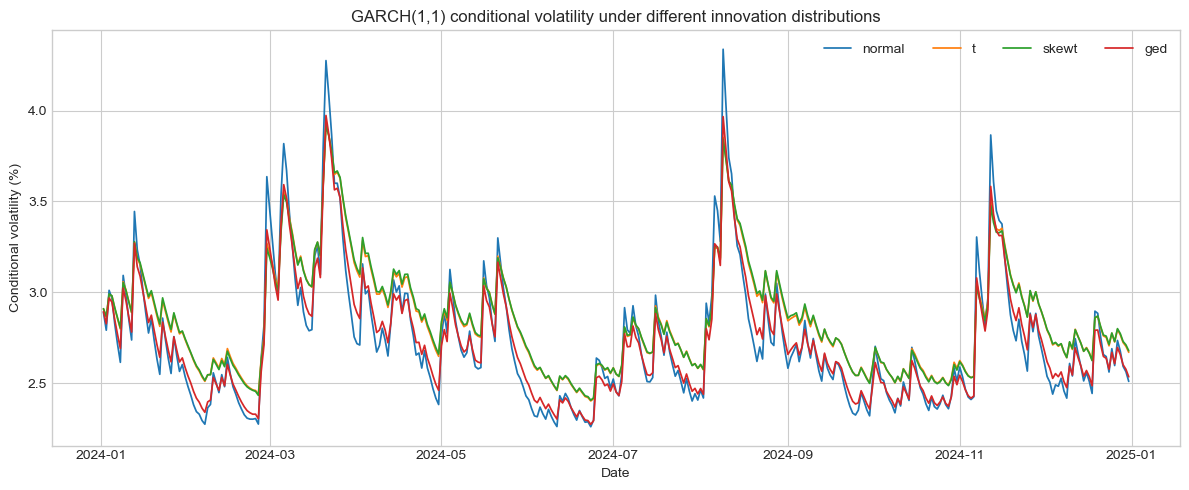

In [8]:

dist_rows = []
garch_dist_fits = {}
vol_by_dist = pd.DataFrame({'Date': btc['Date']})
for dist in ['normal', 't', 'skewt', 'ged']:
    res = arch_model(returns, mean='Constant', vol='GARCH', p=1, q=1, dist=dist, rescale=False).fit(disp='off')
    std_resid = pd.Series(res.std_resid).dropna()
    garch_dist_fits[dist] = res
    vol_by_dist[dist] = res.conditional_volatility.values
    params = res.params
    dist_rows.append({
        'Distribution': dist,
        'AIC': res.aic,
        'BIC': res.bic,
        'Log-likelihood': res.loglikelihood,
        'mu': params.get('mu', np.nan),
        'omega': params.get('omega', np.nan),
        'alpha[1]': params.get('alpha[1]', np.nan),
        'beta[1]': params.get('beta[1]', np.nan),
        'alpha+beta': params.get('alpha[1]', 0.0) + params.get('beta[1]', 0.0),
        'tail/skew parameter 1': params.get('nu', params.get('eta', np.nan)),
        'tail/skew parameter 2': params.get('lambda', np.nan),
        'LB(10) p-value: std resid': acorr_ljungbox(std_resid, lags=[10], return_df=True)['lb_pvalue'].iloc[0],
        'LB(10) p-value: std resid^2': acorr_ljungbox(std_resid ** 2, lags=[10], return_df=True)['lb_pvalue'].iloc[0],
    })

dist_compare = pd.DataFrame(dist_rows)
display(dist_compare)

fig, ax = plt.subplots(figsize=(12, 5))
for dist in ['normal', 't', 'skewt', 'ged']:
    ax.plot(vol_by_dist['Date'], vol_by_dist[dist], linewidth=1.25, label=dist)
ax.set_title('GARCH(1,1) conditional volatility under different innovation distributions')
ax.set_xlabel('Date')
ax.set_ylabel('Conditional volatility (%)')
ax.legend(ncol=4)
plt.tight_layout()
plt.show()



**Answer to 2(b).**

The volatility paths are broadly similar, but the fit improves materially once the innovations are allowed to be heavy-tailed. In this sample, **GED has the best AIC/BIC**, while **Student-t and skewed Student-t are very close to each other** and both dominate the Gaussian specification. So the main conclusion is that **Bitcoin volatility is better modeled with heavy-tailed innovations than with a strict Gaussian assumption**.


In [9]:

garch_ar1_t = arch_model(returns, mean='AR', lags=1, vol='GARCH', p=1, q=1, dist='t', rescale=False).fit(disp='off')
garch_ar1_name = [name for name in garch_ar1_t.params.index if '[' in name][0]

mean_diag_q2 = pd.DataFrame([
    {'Check': 'Raw returns Ljung-Box p-value at lag 10', 'Value': raw_lb.loc[10, 'lb_pvalue']},
    {'Check': 'Raw returns Ljung-Box p-value at lag 20', 'Value': raw_lb.loc[20, 'lb_pvalue']},
    {'Check': 'GARCH(1,1)-t with AR(1) mean: AR coefficient', 'Value': garch_ar1_t.params[garch_ar1_name]},
    {'Check': 'GARCH(1,1)-t with AR(1) mean: AR coefficient p-value', 'Value': garch_ar1_t.pvalues[garch_ar1_name]},
    {'Check': 'GARCH(1,1)-t constant-mean AIC', 'Value': garch_dist_fits['t'].aic},
    {'Check': 'GARCH(1,1)-t AR(1)-mean AIC', 'Value': garch_ar1_t.aic},
])

display(mean_diag_q2)


,Check,Value
0,Raw returns Ljung-Box p-value at lag 10,0.5991
1,Raw returns Ljung-Box p-value at lag 20,0.3416
2,"GARCH(1,1)-t with AR(1) mean: AR coefficient",-0.0710
3,"GARCH(1,1)-t with AR(1) mean: AR coefficient p...",0.1375
4,"GARCH(1,1)-t constant-mean AIC","1,751.0066"
5,"GARCH(1,1)-t AR(1)-mean AIC","1,746.7738"



**Answer to 2(c).**

Again, I do **not** see a compelling need to replace AR(0) by a richer ARMA mean model. The Ljung-Box tests on the raw returns are not significant, and when I add an AR(1) term to the Student-t GARCH(1,1), the AR coefficient is still not statistically significant. So the mean dynamics look weak, while the variance dynamics are the dominant feature.



## Question 3: Compare GARCH(1,1), GJR-GARCH(1,1), and EGARCH(1,1)

Since Question 2 shows that heavy-tailed innovations are important, I keep the innovation distribution fixed at **Student-t** and compare the volatility dynamics across the three model classes.


,Model,AIC,BIC,Log-likelihood,mu,omega,alpha[1],gamma[1],beta[1],nu,LB(10) p-value: std resid,LB(10) p-value: std resid^2
0,"GARCH(1,1)","1,751.0066","1,770.5060",-870.5033,0.1403,0.4989,0.0424,NaN,0.8994,4.0952,0.7264,0.3580
1,"GJR-GARCH(1,1)","1,751.5203","1,774.9197",-869.7602,0.1254,0.9207,0.0230,0.0827,0.8319,4.1082,0.6484,0.1854
2,"EGARCH(1,1)","1,751.9456","1,775.3450",-869.9728,0.1224,0.2976,0.1300,-0.0734,0.8634,4.1415,0.6313,0.1811


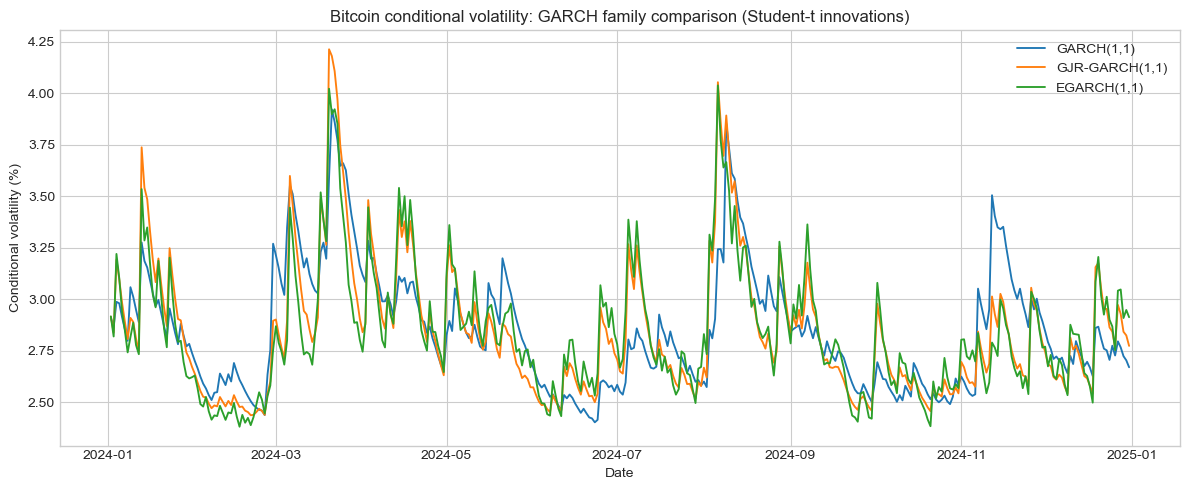

In [10]:

model_specs = {
    'GARCH(1,1)': dict(vol='GARCH', p=1, q=1, o=0),
    'GJR-GARCH(1,1)': dict(vol='GARCH', p=1, o=1, q=1),
    'EGARCH(1,1)': dict(vol='EGARCH', p=1, o=1, q=1),
}

btc_model_rows = []
btc_type_fits = {}
vol_by_type = pd.DataFrame({'Date': btc['Date']})
for name, spec in model_specs.items():
    res = arch_model(returns, mean='Constant', dist='t', rescale=False, **spec).fit(disp='off')
    btc_type_fits[name] = res
    vol_by_type[name] = res.conditional_volatility.values
    std_resid = pd.Series(res.std_resid).dropna()
    params = res.params
    btc_model_rows.append({
        'Model': name,
        'AIC': res.aic,
        'BIC': res.bic,
        'Log-likelihood': res.loglikelihood,
        'mu': params.get('mu', np.nan),
        'omega': params.get('omega', np.nan),
        'alpha[1]': params.get('alpha[1]', np.nan),
        'gamma[1]': params.get('gamma[1]', np.nan),
        'beta[1]': params.get('beta[1]', np.nan),
        'nu': params.get('nu', np.nan),
        'LB(10) p-value: std resid': acorr_ljungbox(std_resid, lags=[10], return_df=True)['lb_pvalue'].iloc[0],
        'LB(10) p-value: std resid^2': acorr_ljungbox(std_resid ** 2, lags=[10], return_df=True)['lb_pvalue'].iloc[0],
    })

btc_type_compare = pd.DataFrame(btc_model_rows)
display(btc_type_compare)

fig, ax = plt.subplots(figsize=(12, 5))
for name in model_specs:
    ax.plot(vol_by_type['Date'], vol_by_type[name], linewidth=1.35, label=name)
ax.set_title('Bitcoin conditional volatility: GARCH family comparison (Student-t innovations)')
ax.set_xlabel('Date')
ax.set_ylabel('Conditional volatility (%)')
ax.legend()
plt.tight_layout()
plt.show()



**Comment on fit and volatility comparison.**

All three models fit the data reasonably well, and all pass the basic residual diagnostics. In this sample, the plain **GARCH(1,1)** has the lowest AIC among the Student-t specifications, while **GJR-GARCH** and **EGARCH** add only a small amount of asymmetry. The estimated asymmetry terms suggest that negative shocks may increase volatility a bit more than positive shocks, but the improvement is limited. So my conclusion is that **Bitcoin volatility persistence is strong, but leverage/asymmetry is only modest in this one-year sample**.



## Question 4 (Optional): SPX GARCH models and Monte Carlo option pricing

I use the **one-year SPX return sample ending on 2024-12-13**, fit Student-t GARCH-family models, and then price the 2025-01-13 SPX options by Monte Carlo.

To keep the exercise transparent, I make the following pricing assumptions:

- European exercise.
- Flat annual risk-free rate of **4.5%**.
- **21 business days** from trade date to expiry.
- Risk-neutral drift is imposed as $r_f/252 - 	frac12 h_t$ in daily log-return units, while the conditional variance paths come from the fitted GARCH-family model.


In [11]:

def load_spx_data(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path)
    df['Date'] = pd.to_datetime(df['Date'])
    df = df.sort_values('Date').reset_index(drop=True)
    df['log_return'] = np.log(df['Adj Close']).diff() * 100
    return df.dropna(subset=['log_return']).reset_index(drop=True)


def load_option_data(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path)
    df = df[df['Type'].notna()].copy()
    for col in ['Strike', 'Bid', 'Mid', 'Ask', 'Last', 'Volume', 'Open Int', 'Delta']:
        df[col] = pd.to_numeric(df[col].astype(str).str.replace(',', '', regex=False), errors='coerce')
    df['IV'] = pd.to_numeric(df['IV'].astype(str).str.rstrip('%'), errors='coerce') / 100
    df = df.dropna(subset=['Strike', 'Mid', 'Type']).copy()
    df = df[(df['Strike'].between(5000, 7000)) & (df['Mid'] > 0)].reset_index(drop=True)
    return df


def price_options_from_forecast(result, spot, annual_rate, steps, maturity_years, option_table, simulations=20000, seed=42):
    fc = result.forecast(
        horizon=steps,
        method='simulation',
        simulations=simulations,
        random_state=np.random.RandomState(seed),
        reindex=False,
    )
    simulated_resid = fc.simulations.residuals[0] / 100.0
    simulated_var = fc.simulations.residual_variances[0] / 10000.0
    simulated_log_returns = (annual_rate / 252.0) - 0.5 * simulated_var + simulated_resid
    terminal_prices = spot * np.exp(simulated_log_returns.sum(axis=1))
    discount = np.exp(-annual_rate * maturity_years)

    priced_parts = []
    for option_type in ['Call', 'Put']:
        subset = option_table[option_table['Type'] == option_type].copy()
        strikes = subset['Strike'].to_numpy()
        if option_type == 'Call':
            payoffs = np.maximum(terminal_prices[:, None] - strikes[None, :], 0.0)
        else:
            payoffs = np.maximum(strikes[None, :] - terminal_prices[:, None], 0.0)
        subset['ModelPrice'] = discount * payoffs.mean(axis=0)
        subset['AbsError'] = (subset['ModelPrice'] - subset['Mid']).abs()
        subset['SqError'] = (subset['ModelPrice'] - subset['Mid']) ** 2
        priced_parts.append(subset)

    priced = pd.concat(priced_parts, ignore_index=True)
    summary = {
        'RMSE': np.sqrt(priced['SqError'].mean()),
        'MAE': priced['AbsError'].mean(),
        'Call_MAE': priced.loc[priced['Type'] == 'Call', 'AbsError'].mean(),
        'Put_MAE': priced.loc[priced['Type'] == 'Put', 'AbsError'].mean(),
    }
    return priced, summary


spx = load_spx_data(DATA_DIR / 'spx_data(1).csv')
options = load_option_data(DATA_DIR / '$spx-options-exp-2025-01-13-weekly-show-all-stacked-12-13-2024.csv')

trade_date = pd.Timestamp('2024-12-13')
expiry = pd.Timestamp('2025-01-13')
spx_train = spx[(spx['Date'] <= trade_date) & (spx['Date'] >= trade_date - pd.DateOffset(years=1))].copy()
spot = float(spx.loc[spx['Date'] == trade_date, 'Adj Close'].iloc[0])
steps_to_expiry = len(pd.bdate_range(trade_date + pd.Timedelta(days=1), expiry))
T = (expiry - trade_date).days / 365.0
risk_free_rate = 0.045

spx_overview = pd.DataFrame({
    'Item': ['Trade date', 'Expiry', 'Spot level', 'Training sample start', 'Training sample end', 'Training observations', 'Business days to expiry', 'Risk-free rate'],
    'Value': [trade_date.date(), expiry.date(), spot, spx_train['Date'].min().date(), spx_train['Date'].max().date(), len(spx_train), steps_to_expiry, risk_free_rate]
})

display(spx_overview)
display(options.head())


,Item,Value
0,Trade date,2024-12-13
1,Expiry,2025-01-13
2,Spot level,"6,051.0898"
3,Training sample start,2023-12-13
4,Training sample end,2024-12-13
5,Training observations,253
6,Business days to expiry,21
7,Risk-free rate,0.0450


,Strike,Moneyness,Bid,Mid,Ask,Last,Change,%Chg,Volume,Open Int,OI Chg,Delta,IV,Type,Time
0,"5,000.0000",17.37%,"1,067.0000","1,077.2000","1,087.4000","1,091.7100",unch,unch,0.0000,1.0000,unch,0.9753,0.3438,Call,2012/9/24
1,"5,100.0000",15.72%,968.1000,978.2000,988.3000,0.0000,unch,unch,0.0000,0.0000,unch,0.9712,0.3192,Call,NaN
2,"5,200.0000",14.07%,868.9000,879.1500,889.4000,0.0000,unch,unch,0.0000,0.0000,unch,0.9667,0.2935,Call,NaN
3,"5,300.0000",12.41%,770.1000,780.3000,790.5000,0.0000,unch,unch,0.0000,0.0000,unch,0.9606,0.2684,Call,NaN
4,"5,400.0000",10.76%,671.8000,681.6500,691.5000,0.0000,unch,unch,0.0000,0.0000,unch,0.9526,0.2435,Call,NaN


In [12]:

spx_fit_rows = []
spx_pricing_rows = []
spx_priced_quotes = {}
spx_fit_results = {}

for name, spec in model_specs.items():
    res = arch_model(spx_train['log_return'], mean='Constant', dist='t', rescale=False, **spec).fit(disp='off')
    spx_fit_results[name] = res
    params = res.params
    spx_fit_rows.append({
        'Model': name,
        'AIC': res.aic,
        'BIC': res.bic,
        'Log-likelihood': res.loglikelihood,
        'mu': params.get('mu', np.nan),
        'omega': params.get('omega', np.nan),
        'alpha[1]': params.get('alpha[1]', np.nan),
        'gamma[1]': params.get('gamma[1]', np.nan),
        'beta[1]': params.get('beta[1]', np.nan),
        'nu': params.get('nu', np.nan),
    })

    priced_quotes, pricing_summary = price_options_from_forecast(
        res,
        spot=spot,
        annual_rate=risk_free_rate,
        steps=steps_to_expiry,
        maturity_years=T,
        option_table=options,
        simulations=20000,
        seed=42,
    )
    priced_quotes['Model'] = name
    spx_priced_quotes[name] = priced_quotes
    spx_pricing_rows.append({
        'Model': name,
        **pricing_summary,
    })

spx_fit_compare = pd.DataFrame(spx_fit_rows)
spx_pricing_compare = pd.DataFrame(spx_pricing_rows)

display(spx_fit_compare)
display(spx_pricing_compare.sort_values('MAE'))


,Model,AIC,BIC,Log-likelihood,mu,omega,alpha[1],gamma[1],beta[1],nu
0,"GARCH(1,1)",572.7765,590.4435,-281.3883,0.1366,0.0531,0.0888,NaN,0.8235,6.2514
1,"GJR-GARCH(1,1)",565.1070,586.3073,-276.5535,0.1091,0.0564,0.0000,0.2062,0.7975,6.5901
2,"EGARCH(1,1)",558.4153,579.6156,-273.2077,0.0989,-0.0633,0.0022,-0.2841,0.9113,6.2868


,Model,RMSE,MAE,Call_MAE,Put_MAE
1,"GJR-GARCH(1,1)",7.4153,6.5134,6.8122,6.2145
0,"GARCH(1,1)",8.9589,8.0043,8.1898,7.8188
2,"EGARCH(1,1)",10.0137,8.3049,6.6399,9.9699


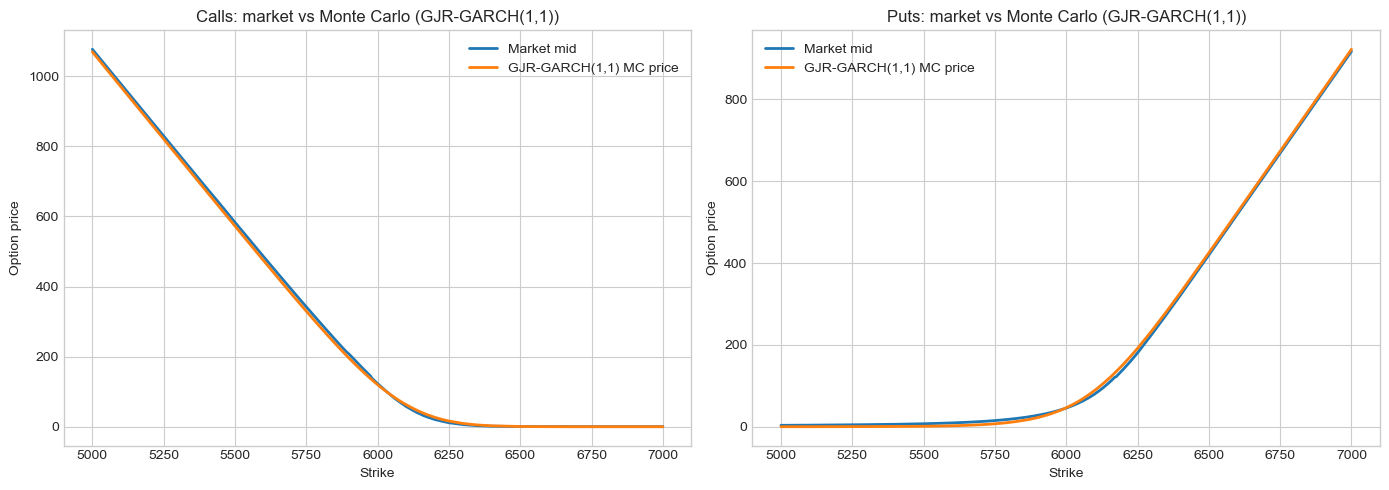

In [13]:

best_pricing_model = spx_pricing_compare.sort_values('MAE').iloc[0]['Model']
best_quotes = spx_priced_quotes[best_pricing_model]

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)
for ax, option_type in zip(axes, ['Call', 'Put']):
    subset = best_quotes[best_quotes['Type'] == option_type].sort_values('Strike')
    ax.plot(subset['Strike'], subset['Mid'], label='Market mid', linewidth=2)
    ax.plot(subset['Strike'], subset['ModelPrice'], label=f'{best_pricing_model} MC price', linewidth=2)
    ax.set_title(f'{option_type}s: market vs Monte Carlo ({best_pricing_model})')
    ax.set_xlabel('Strike')
    ax.set_ylabel('Option price')
    ax.legend()
plt.tight_layout()
plt.show()



**Optional-section conclusion.**

On the one-year SPX sample, the **EGARCH(1,1)-t** model has the best in-sample likelihood and the lowest AIC/BIC, which suggests that asymmetric volatility matters for equities more than it did for Bitcoin in this sample. However, under the simple risk-neutral Monte Carlo pricing setup used here, **GJR-GARCH(1,1)-t** produces the lowest pricing MAE against the option mid quotes.

So the optional exercise suggests two things:

1. Asymmetric volatility models are useful for SPX returns.
2. The model that fits historical returns best is **not necessarily** the model that prices the cross-section of options best once we move to a simplified pricing framework.
